# Exploración de `user`

Este notebook analiza **únicamente la tabla `user`** (`data/processed/user.csv`), la versión ya
depurada en `notebooks/presentation/presentation_processing.ipynb`.

* **Unidad de análisis:** un usuario. Cada fila es una persona distinta, así que `n = 943`.
* **Qué se estudia:** la composición demográfica de la muestra (edad, género, ocupación, código postal)
  y las relaciones entre esas variables.
* **Qué NO se estudia aquí:** nada relacionado con las calificaciones ni con las películas; eso
  corresponde a los notebooks `data.ipynb`, `item.ipynb` y `data_user.ipynb`.
* **Advertencia de alcance:** los usuarios de MovieLens (1997-1998) se auto-seleccionaron y todos tienen
  al menos 19 calificaciones. Es una **muestra no probabilística**: describe a los usuarios del sistema,
  no a la población general de espectadores.

## 1. Importación de librerías y datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Estilo común para todas las figuras del notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
# zip_code se lee como texto a propósito: contiene códigos postales canadienses (con letras)
# y códigos de EE. UU. con ceros a la izquierda que se perderían si pandas los leyera como número.
user = pd.read_csv("../../data/processed/user.csv", dtype={"zip_code": str})
user.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


## 2. Exploración inicial y calidad de los datos

**Qué se calcula:** dimensiones, tipos de dato, valores nulos, filas duplicadas, unicidad de `user_id`
y cardinalidad de cada columna.

**Por qué es relevante:** fija el `n` con el que se trabajará y descarta problemas de integridad antes
de interpretar cualquier estadístico. Si `user_id` no fuera único, el cruce con `data` duplicaría filas.

In [3]:
print(f"Registros: {user.shape[0]}\nColumnas: {user.shape[1]}\n")

print("Tipos de dato por columna:")
print(user.dtypes, "\n")

print("Valores nulos por columna:")
print(user.isnull().sum(), "\n")

print("Valores distintos por columna:")
print(user.nunique(), "\n")

print(f"Filas completamente duplicadas: {user.duplicated().sum()}")
print(f"user_id duplicados: {user['user_id'].duplicated().sum()}")

rango_completo = user["user_id"].max() - user["user_id"].min() + 1 == user.shape[0]
print(f"user_id cubre el rango {user['user_id'].min()}-{user['user_id'].max()} sin saltos: {rango_completo}")

Registros: 943
Columnas: 5

Tipos de dato por columna:
user_id       int64
age           int64
gender          str
occupation      str
zip_code        str
dtype: object 

Valores nulos por columna:
user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64 

Valores distintos por columna:
user_id       943
age            61
gender          2
occupation     21
zip_code      795
dtype: int64 

Filas completamente duplicadas: 0
user_id duplicados: 0
user_id cubre el rango 1-943 sin saltos: True


**Resultados:** 943 filas y 5 columnas, sin valores nulos, sin filas duplicadas y con `user_id`
único y consecutivo de 1 a 943.

**Conclusión:** la tabla está limpia y `user_id` sirve como clave primaria. Los tipos son coherentes:
`age` es cuantitativa discreta; `gender` y `occupation` son categóricas nominales; `zip_code` es un
identificador de texto con 795 valores distintos (alta cardinalidad, ver sección 7).

### Funciones auxiliares

Se definen una sola vez para no repetir código en el resto del notebook.

In [4]:
def resumen_numerico(serie, nombre):
    """Medidas de tendencia central, dispersión y forma de una variable cuantitativa."""
    q1, q3 = serie.quantile([0.25, 0.75])
    return pd.Series(
        {
            "n": serie.size,
            "media": serie.mean(),
            "mediana": serie.median(),
            "moda": serie.mode().iloc[0],
            "desv_est": serie.std(),
            "minimo": serie.min(),
            "Q1": q1,
            "Q3": q3,
            "maximo": serie.max(),
            "IQR": q3 - q1,
            "asimetria": serie.skew(),
        },
        name=nombre,
    ).round(3)


def wilson_ic(exitos, n, confianza=0.95):
    """Intervalo de confianza para una proporción (método de Wilson)."""
    z = stats.norm.ppf(1 - (1 - confianza) / 2)
    p = exitos / n
    denominador = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / denominador
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominador
    return centro - margen, centro + margen


def cliffs_delta(a, b):
    """Tamaño del efecto no paramétrico. Referencia: |d| < 0.147 despreciable,
    < 0.33 pequeño, < 0.474 mediano, en adelante grande."""
    u, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    return 2 * u / (len(a) * len(b)) - 1


def epsilon_cuadrado(h, k, n):
    """Tamaño del efecto para Kruskal-Wallis: proporción de la variabilidad de los rangos explicada."""
    return (h - k + 1) / (n - k)

## 3. Edad

### 3.1 Estadísticas descriptivas

**Qué se calcula:** tendencia central (media, mediana, moda), dispersión (desviación estándar, IQR),
posición (mínimo, cuartiles, máximo) y forma (asimetría).

**Por qué es relevante:** la edad es la única variable cuantitativa de la tabla; su forma decide qué
pruebas estadísticas son válidas más adelante (paramétricas vs. no paramétricas).

In [5]:
resumen_numerico(user["age"], "age")

n            943.000
media         34.052
mediana       31.000
moda          30.000
desv_est      12.193
minimo         7.000
Q1            25.000
Q3            43.000
maximo        73.000
IQR           18.000
asimetria      0.605
Name: age, dtype: float64

In [6]:
q1, q3 = user["age"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atipicos = user.loc[(user["age"] < limite_inf) | (user["age"] > limite_sup), "age"]

print(f"Criterio 1.5*IQR -> límites [{limite_inf:.1f}, {limite_sup:.1f}]")
print(f"Usuarios atípicos: {atipicos.size} ({atipicos.size / user.shape[0] * 100:.2f}%)"
      f" -> edades {sorted(int(edad) for edad in atipicos.unique())}")

Criterio 1.5*IQR -> límites [-2.0, 70.0]
Usuarios atípicos: 1 (0.11%) -> edades [73]


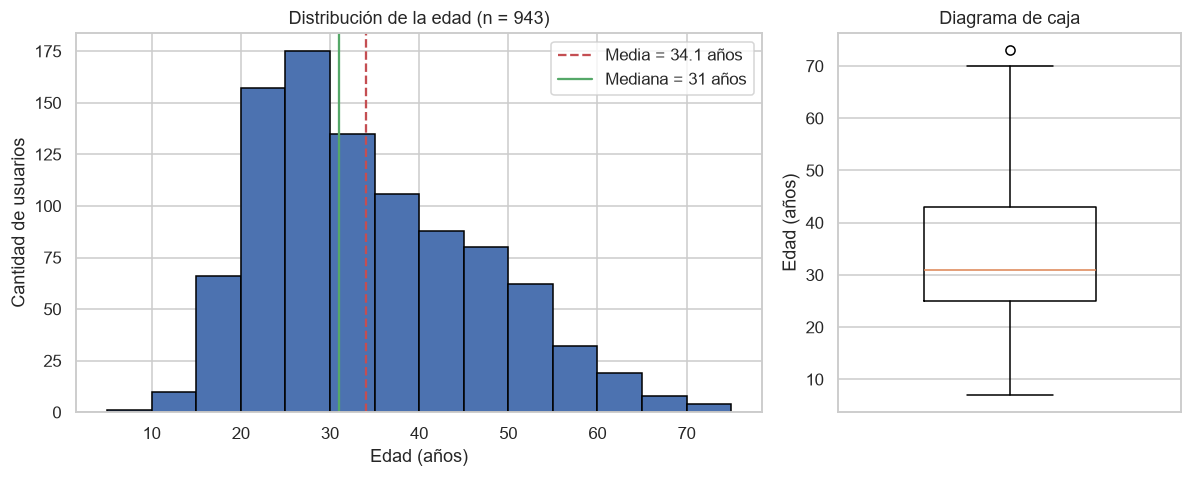

In [7]:
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [2, 1]})

ax_hist.hist(user["age"], bins=range(5, 80, 5), color="#4C72B0", edgecolor="black")
ax_hist.axvline(user["age"].mean(), color="#C44E52", linestyle="--",
                label=f"Media = {user['age'].mean():.1f} años")
ax_hist.axvline(user["age"].median(), color="#55A868", linestyle="-",
                label=f"Mediana = {user['age'].median():.0f} años")
ax_hist.set_xlabel("Edad (años)")
ax_hist.set_ylabel("Cantidad de usuarios")
ax_hist.set_title("Distribución de la edad (n = 943)")
ax_hist.legend()

ax_box.boxplot(user["age"], widths=0.5)
ax_box.set_ylabel("Edad (años)")
ax_box.set_title("Diagrama de caja")
ax_box.set_xticks([])

fig.tight_layout()
plt.show()

**Resultados:** media 34.05 años, mediana 31, moda 30, desviación estándar 12.19
(coeficiente de variación 0.36), rango de 7 a 73 años, Q1 = 25, Q3 = 43, IQR = 18 y asimetría +0.605.
El criterio 1.5·IQR marca un único usuario atípico (73 años).

**Conclusión:** la distribución es **unimodal y asimétrica a la derecha**: la mitad de los usuarios tiene
entre 25 y 43 años, y la cola larga la forman los usuarios mayores. Como media > mediana, la media
sobreestima la edad "típica", así que se reporta la mediana como referencia. Esa asimetría también
justifica usar **pruebas no paramétricas** en las secciones 5 y 6. El valor atípico (73 años) es una edad
perfectamente plausible, de modo que **no se elimina**: es un extremo real, no un error de captura.

### 3.2 Grupos de edad

**Qué se calcula:** tabla de frecuencias absolutas, relativas y acumuladas por tramo etario.

**Por qué es relevante:** agrupar permite comparar tramos con otras variables categóricas y sirve de
base para el análisis de `user + data`. Los tramos siguen cortes demográficos habituales (menores de
edad, jóvenes, adultos jóvenes, adultos, adultos mayores).

In [8]:
BINS_EDAD = [6, 17, 24, 34, 44, 54, 73]
ETIQUETAS_EDAD = ["7-17", "18-24", "25-34", "35-44", "45-54", "55-73"]
user["grupo_edad"] = pd.cut(user["age"], bins=BINS_EDAD, labels=ETIQUETAS_EDAD)

conteo_grupo = user["grupo_edad"].value_counts().sort_index()
tabla_grupos = pd.DataFrame({
    "usuarios": conteo_grupo,
    "porcentaje": (conteo_grupo / user.shape[0] * 100).round(2),
    "porcentaje_acumulado": (conteo_grupo.cumsum() / user.shape[0] * 100).round(2),
})
tabla_grupos

,usuarios,porcentaje,porcentaje_acumulado
grupo_edad,,,
7-17,36,3.82,3.82
18-24,198,21.00,24.81
25-34,310,32.87,57.69
35-44,194,20.57,78.26
45-54,142,15.06,93.32
55-73,63,6.68,100.00


**Resultados:** 25-34 años es el grupo más numeroso (310 usuarios, 32.9 %), seguido de 18-24
(198, 21.0 %) y 35-44 (194, 20.6 %). Los menores de 18 son apenas 36 (3.8 %) y los de 55 o más, 63 (6.7 %).

**Conclusión:** cerca del 74 % de la muestra tiene entre 18 y 44 años. Los grupos extremos son pequeños,
así que cualquier comparación que los involucre tendrá **poca precisión** y deberá leerse con cautela
(intervalos de confianza anchos).

## 4. Género y ocupación

**Qué se calcula:** tablas de frecuencia con porcentajes y, para el género, un intervalo de confianza
del 95 % (método de Wilson) para la proporción de mujeres.

**Por qué es relevante:** describe el desbalance de la muestra, dato necesario para interpretar
correctamente cualquier comparación entre grupos posterior. El IC cuantifica la precisión de la
proporción observada **en esta muestra**; no la extrapola a ninguna población externa.

In [9]:
conteo_genero = user["gender"].value_counts()
tabla_genero = pd.DataFrame({
    "usuarios": conteo_genero,
    "porcentaje": (conteo_genero / user.shape[0] * 100).round(2),
})

ic_bajo, ic_alto = wilson_ic((user["gender"] == "F").sum(), user.shape[0])
print(f"Proporción de mujeres: {(user['gender'] == 'F').mean():.4f}")
print(f"IC 95% (Wilson): [{ic_bajo:.4f}, {ic_alto:.4f}]")
print(f"Razón hombres/mujeres: {conteo_genero['M'] / conteo_genero['F']:.2f} a 1\n")
tabla_genero

Proporción de mujeres: 0.2895
IC 95% (Wilson): [0.2615, 0.3193]
Razón hombres/mujeres: 2.45 a 1



,usuarios,porcentaje
gender,,
M,670,71.05
F,273,28.95


In [10]:
conteo_ocupacion = user["occupation"].value_counts()
tabla_ocupacion = pd.DataFrame({
    "usuarios": conteo_ocupacion,
    "porcentaje": (conteo_ocupacion / user.shape[0] * 100).round(2),
})

print(f"Ocupaciones distintas: {user['occupation'].nunique()}")
print(f"Ocupaciones con menos de 10 usuarios: {sorted(conteo_ocupacion[conteo_ocupacion < 10].index)}\n")
tabla_ocupacion

Ocupaciones distintas: 21
Ocupaciones con menos de 10 usuarios: ['doctor', 'homemaker', 'none']



,usuarios,porcentaje
occupation,,
student,196,20.78
other,105,11.13
educator,95,10.07
administrator,79,8.38
engineer,67,7.10
programmer,66,7.00
librarian,51,5.41
writer,45,4.77
executive,32,3.39


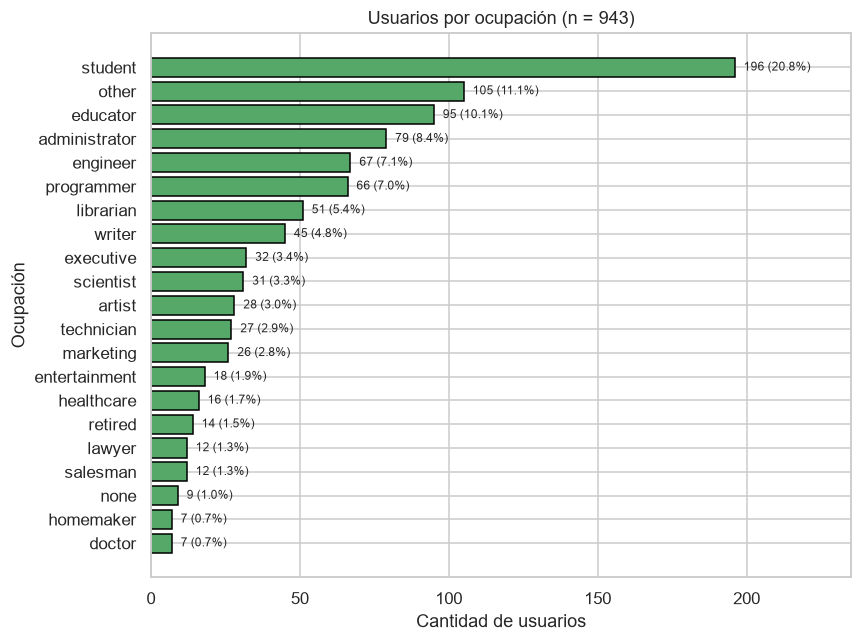

In [11]:
orden = conteo_ocupacion.sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(orden.index, orden.values, color="#55A868", edgecolor="black")
for posicion, valor in enumerate(orden.values):
    ax.text(valor + 3, posicion, f"{valor} ({valor / user.shape[0] * 100:.1f}%)", va="center", fontsize=8)

ax.set_xlim(0, orden.max() * 1.2)
ax.set_xlabel("Cantidad de usuarios")
ax.set_ylabel("Ocupación")
ax.set_title("Usuarios por ocupación (n = 943)")
fig.tight_layout()
plt.show()

**Resultados:** 670 hombres (71.05 %) y 273 mujeres (28.95 %), razón de 2.45 a 1; el IC 95 % de
Wilson para la proporción de mujeres es [0.262, 0.319]. Hay 21 ocupaciones: `student` domina con 196
usuarios (20.8 %), seguida de `other` (11.1 %) y `educator` (10.1 %); `doctor`, `homemaker` y `none`
tienen menos de 10 usuarios cada una.

**Conclusión:** la muestra está **fuertemente desbalanceada por género** y muy concentrada en unas pocas
ocupaciones. Dos consecuencias prácticas: (1) las comparaciones por género serán mucho más precisas en
el grupo masculino; (2) las ocupaciones con `n < 20` no permiten estimaciones fiables y se excluirán de
las pruebas estadísticas, indicándolo de forma explícita.

*No se grafica el género*: una tabla de dos categorías comunica lo mismo que un gráfico, y con más precisión.

## 5. Edad según género

**Qué se calcula:** descriptivos de edad por género, prueba de normalidad (Shapiro-Wilk) y prueba de
**Mann-Whitney U** con su tamaño del efecto (delta de Cliff).

**Pregunta que responde:** ¿la distribución de edades difiere entre hombres y mujeres en esta muestra?

**Hipótesis:** H₀: ambas distribuciones de edad son iguales (P(X > Y) = P(Y > X)). H₁: difieren.

**Supuestos:** observaciones independientes (✓: cada fila es un usuario distinto) y variable al menos
ordinal (✓). Mann-Whitney **no** exige normalidad, a diferencia de la prueba t; Shapiro-Wilk se usa solo
para justificar esa elección.

In [12]:
edad_f = user.loc[user["gender"] == "F", "age"]
edad_m = user.loc[user["gender"] == "M", "age"]

print(user.groupby("gender")["age"].agg(["size", "mean", "std", "median", "min", "max"]).round(2), "\n")

print("Shapiro-Wilk (H0: la edad se distribuye normal):")
print(f"  Mujeres: p = {stats.shapiro(edad_f).pvalue:.2e}")
print(f"  Hombres: p = {stats.shapiro(edad_m).pvalue:.2e}")

u_estadistico, p_edad_genero = stats.mannwhitneyu(edad_f, edad_m, alternative="two-sided")
print(f"\nMann-Whitney U = {u_estadistico:.1f} | p = {p_edad_genero:.4f}"
      f" | delta de Cliff = {cliffs_delta(edad_f, edad_m):.4f}")

        size   mean    std  median  min  max
gender                                      
F        273  33.81  11.80    32.0   13   70
M        670  34.15  12.36    31.0    7   73 

Shapiro-Wilk (H0: la edad se distribuye normal):
  Mujeres: p = 6.25e-06
  Hombres: p = 3.01e-14

Mann-Whitney U = 91292.5 | p = 0.9659 | delta de Cliff = -0.0018


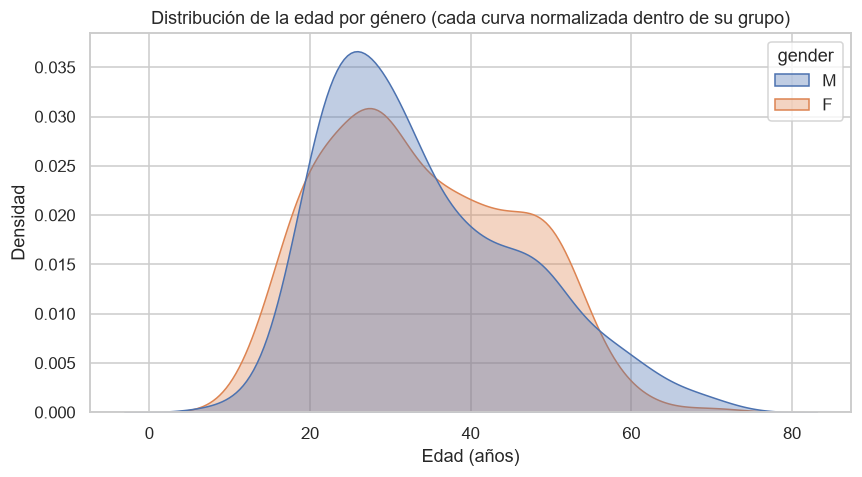

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(data=user, x="age", hue="gender", fill=True, common_norm=False, alpha=0.35, ax=ax)
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de la edad por género (cada curva normalizada dentro de su grupo)")
fig.tight_layout()
plt.show()

**Resultados:** mujeres 33.81 años de media (mediana 32), hombres 34.15 (mediana 31). Shapiro-Wilk
rechaza la normalidad en ambos grupos (p < 0.001), lo que confirma que la prueba no paramétrica era la
opción correcta. Mann-Whitney da **p = 0.966** con **delta de Cliff = -0.002** (efecto despreciable).

**Conclusión:** **no hay evidencia de diferencia de edad entre géneros**; las curvas de densidad se
superponen casi por completo. Un p-valor alto no "demuestra" que las distribuciones sean idénticas: solo
indica que con estos datos no se detecta diferencia. El tamaño del efecto, prácticamente nulo, refuerza
que si existiera alguna diferencia sería irrelevante en la práctica.

## 6. Edad y género según ocupación

### 6.1 Edad por ocupación

**Qué se calcula:** **Kruskal-Wallis** (alternativa no paramétrica al ANOVA de un factor) sobre la edad,
con épsilon² como tamaño del efecto.

**Hipótesis:** H₀: la distribución de la edad es la misma en todas las ocupaciones. H₁: al menos una difiere.

**Supuestos:** independencia entre observaciones (✓) y variable ordinal (✓). Se excluyen las ocupaciones
con menos de 20 usuarios porque con un `n` tan pequeño la prueba tiene muy poca potencia y las medianas
son inestables.

In [14]:
ocupaciones_validas = conteo_ocupacion[conteo_ocupacion >= 20].index.tolist()
sub_ocupacion = user[user["occupation"].isin(ocupaciones_validas)]
excluidas = sorted(set(conteo_ocupacion.index) - set(ocupaciones_validas))

print(f"Ocupaciones analizadas ({len(ocupaciones_validas)}): {sorted(ocupaciones_validas)}")
print(f"Excluidas por n < 20 ({len(excluidas)}): {excluidas}")
print(f"Usuarios incluidos: {sub_ocupacion.shape[0]} de {user.shape[0]}\n")

grupos_edad = [sub_ocupacion.loc[sub_ocupacion["occupation"] == o, "age"].values
               for o in ocupaciones_validas]
h_edad_ocup, p_edad_ocup = stats.kruskal(*grupos_edad)

print(f"Kruskal-Wallis H = {h_edad_ocup:.2f} | gl = {len(grupos_edad) - 1} | p = {p_edad_ocup:.3e}")
print(f"epsilon^2 = {epsilon_cuadrado(h_edad_ocup, len(grupos_edad), sub_ocupacion.shape[0]):.3f}")

Ocupaciones analizadas (13): ['administrator', 'artist', 'educator', 'engineer', 'executive', 'librarian', 'marketing', 'other', 'programmer', 'scientist', 'student', 'technician', 'writer']
Excluidas por n < 20 (8): ['doctor', 'entertainment', 'healthcare', 'homemaker', 'lawyer', 'none', 'retired', 'salesman']
Usuarios incluidos: 848 de 943

Kruskal-Wallis H = 342.00 | gl = 12 | p = 6.821e-66
epsilon^2 = 0.395


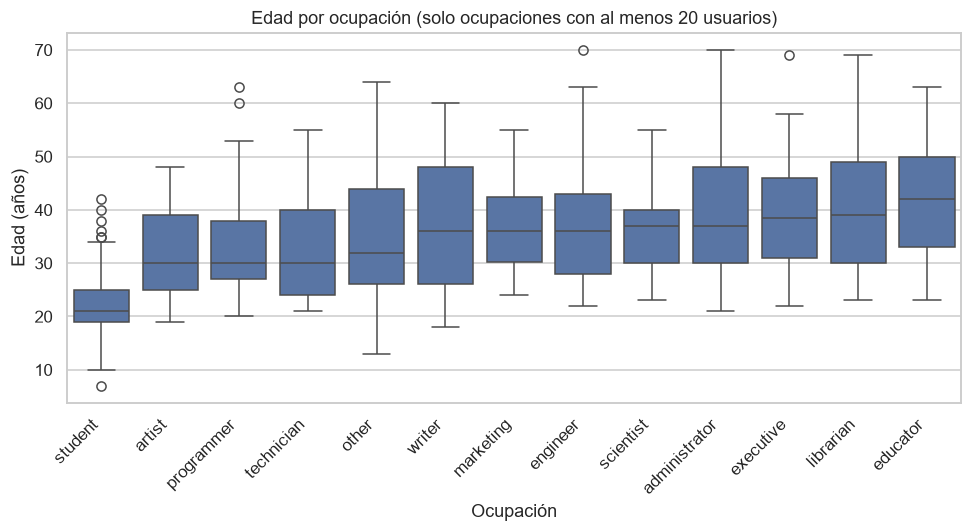

In [15]:
orden_mediana = sub_ocupacion.groupby("occupation")["age"].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=sub_ocupacion, x="occupation", y="age", order=orden_mediana, color="#4C72B0", ax=ax)
ax.set_xlabel("Ocupación")
ax.set_ylabel("Edad (años)")
ax.set_title("Edad por ocupación (solo ocupaciones con al menos 20 usuarios)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.show()

**Resultados:** H = 342.0 con p ≈ 7·10⁻⁶⁶ y **épsilon² = 0.395**: la ocupación explica cerca del
40 % de la variabilidad de los rangos de edad, un efecto **grande**. `student` es la ocupación más joven
(mediana 21 años) y `educator` (42) y `librarian` (39) las de mayor edad entre las analizadas. Fuera del
análisis, `retired` promedia 63.1 años, pero con n = 14 no es contrastable.

**Conclusión:** edad y ocupación están fuertemente asociadas, en la dirección esperable. Esto tiene una
implicación metodológica importante para el resto del trabajo: **edad y ocupación no son variables
independientes**, de modo que una diferencia atribuida a la ocupación puede deberse en parte a la edad
(y viceversa). Con estos datos no es posible separar un efecto del otro.

### 6.2 Género por ocupación

**Qué se calcula:** tabla de contingencia ocupación × género y **prueba chi-cuadrado de independencia**,
con V de Cramér como tamaño del efecto.

**Hipótesis:** H₀: ocupación y género son independientes. H₁: están asociados.

**Supuesto crítico:** al menos el 80 % de las celdas debe tener frecuencia **esperada** ≥ 5. Se verifica
en el código: con las 21 ocupaciones el supuesto **no** se cumple, así que la prueba se aplica solo al
subconjunto de ocupaciones con n ≥ 20, donde sí se cumple.

In [16]:
tabla_cruzada = pd.crosstab(user["occupation"], user["gender"])

_, _, _, esperadas_total = stats.chi2_contingency(tabla_cruzada)
print("Tabla completa (21 ocupaciones):")
print(f"  celdas con frecuencia esperada < 5: {(esperadas_total < 5).sum()} de {esperadas_total.size}"
      f" (mínima = {esperadas_total.min():.2f}) -> supuesto INCUMPLIDO, no se aplica la prueba\n")

tabla_valida = tabla_cruzada.loc[ocupaciones_validas]
chi2, p_genero_ocup, gl, esperadas = stats.chi2_contingency(tabla_valida)
v_cramer = np.sqrt(chi2 / (tabla_valida.values.sum() * (min(tabla_valida.shape) - 1)))

print(f"Subconjunto con n >= 20 ({len(ocupaciones_validas)} ocupaciones):")
print(f"  celdas con frecuencia esperada < 5: {(esperadas < 5).sum()}"
      f" (mínima = {esperadas.min():.2f}) -> supuesto CUMPLIDO")
print(f"  Chi-cuadrado = {chi2:.2f} | gl = {gl} | p = {p_genero_ocup:.3e} | V de Cramér = {v_cramer:.3f}")

Tabla completa (21 ocupaciones):
  celdas con frecuencia esperada < 5: 9 de 42 (mínima = 2.03) -> supuesto INCUMPLIDO, no se aplica la prueba

Subconjunto con n >= 20 (13 ocupaciones):
  celdas con frecuencia esperada < 5: 0 (mínima = 7.48) -> supuesto CUMPLIDO
  Chi-cuadrado = 95.79 | gl = 12 | p = 3.703e-15 | V de Cramér = 0.336


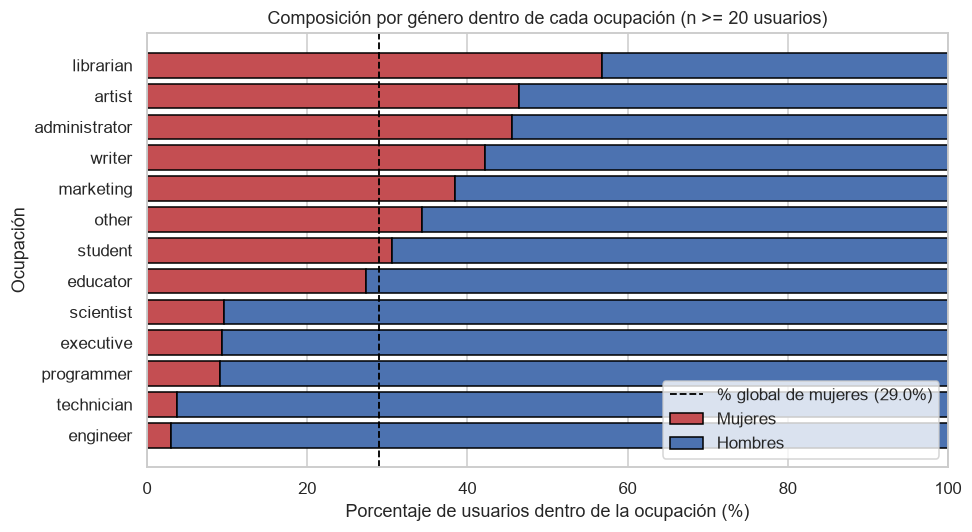

In [17]:
porcentajes = tabla_valida.div(tabla_valida.sum(axis=1), axis=0).mul(100).sort_values("F")
pct_mujeres_global = (user["gender"] == "F").mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(porcentajes.index, porcentajes["F"], color="#C44E52", edgecolor="black", label="Mujeres")
ax.barh(porcentajes.index, porcentajes["M"], left=porcentajes["F"], color="#4C72B0",
        edgecolor="black", label="Hombres")
ax.axvline(pct_mujeres_global, color="black", linestyle="--", linewidth=1.2,
           label=f"% global de mujeres ({pct_mujeres_global:.1f}%)")

ax.set_xlim(0, 100)
ax.set_xlabel("Porcentaje de usuarios dentro de la ocupación (%)")
ax.set_ylabel("Ocupación")
ax.set_title("Composición por género dentro de cada ocupación (n >= 20 usuarios)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**Resultados:** con las 21 ocupaciones, 9 de 42 celdas tienen frecuencia esperada < 5 (mínima 2.03),
por lo que el chi-cuadrado global **no es válido**. Restringido a las 13 ocupaciones con n ≥ 20 el
supuesto se cumple (esperada mínima 7.48) y da χ² = 95.79, gl = 12, **p ≈ 3.7·10⁻¹⁵**, con
**V de Cramér = 0.336** (asociación moderada).

**Conclusión:** género y ocupación **sí están asociados** en esta muestra. La línea del 29 % (proporción
global de mujeres) muestra dónde está la desviación: `librarian` (56.9 % mujeres), `artist` (46.4 %) y
`administrator` (45.6 %) quedan muy por encima, mientras que `engineer` (3.0 %), `technician` (3.7 %) y
`programmer` (9.1 %) quedan muy por debajo.

**Limitación:** esto describe **quién usaba MovieLens en 1997-98**, no la composición real de esas
profesiones. Además la prueba detecta asociación, no causa, y no señala qué celdas concretas la generan
(eso exigiría analizar los residuos estandarizados).

## 7. Código postal

**Qué se calcula:** cardinalidad, repeticiones y distribución por primer dígito del ZIP estadounidense.

**Por qué es relevante:** justificar hasta dónde puede usarse esta variable. Con 795 valores distintos
entre 943 usuarios, `zip_code` funciona casi como un identificador y **no admite tratarse como categoría**
en comparaciones de grupos.

In [18]:
zips = user["zip_code"]
formato_us = zips.str.match(r"^\d{5}$")
repeticiones = zips.value_counts()

print(f"Códigos postales distintos: {zips.nunique()} entre {zips.size} usuarios")
print(f"Códigos compartidos por más de un usuario: {(repeticiones > 1).sum()}"
      f" (máximo {repeticiones.max()} usuarios en '{repeticiones.idxmax()}')")
print(f"Códigos fuera del formato de 5 dígitos de EE. UU.: {(~formato_us).sum()}"
      f" -> ejemplos {zips[~formato_us].head(4).tolist()} (formato canadiense)")

Códigos postales distintos: 795 entre 943 usuarios
Códigos compartidos por más de un usuario: 102 (máximo 9 usuarios en '55414')
Códigos fuera del formato de 5 dígitos de EE. UU.: 18 -> ejemplos ['T8H1N', 'V3N4P', 'L9G2B', 'E2A4H'] (formato canadiense)


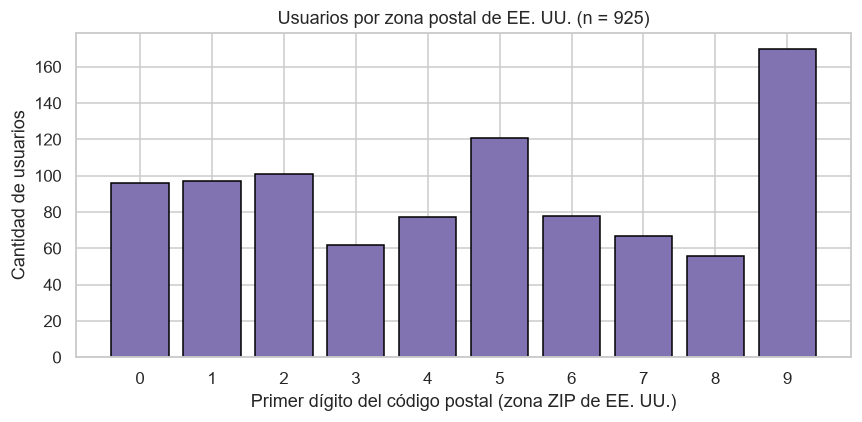

In [19]:
zonas = zips[formato_us].str[0].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(zonas.index, zonas.values, color="#8172B2", edgecolor="black")
ax.set_xlabel("Primer dígito del código postal (zona ZIP de EE. UU.)")
ax.set_ylabel("Cantidad de usuarios")
ax.set_title(f"Usuarios por zona postal de EE. UU. (n = {int(zonas.sum())})")
fig.tight_layout()
plt.show()

**Resultados:** 795 códigos distintos, de los cuales solo 102 son compartidos por más de un usuario
(el más repetido, `55414`, con 9). 18 usuarios tienen códigos canadienses. Por zona ZIP, la 9 (costa
oeste de EE. UU.) concentra 170 usuarios y la 5 (norte central, que incluye Minnesota) 121.

**Conclusión:** la variable aporta poco por sí sola. El único patrón defendible es la concentración en
las zonas 9 y 5, coherente con que MovieLens nació en la Universidad de Minnesota (`55414` es
precisamente un código de Minneapolis).

**Limitación explícita:** el repositorio no incluye ninguna tabla que traduzca ZIP a ciudad o estado, y
el prefijo numérico solo delimita regiones muy amplias. Por eso **no se realiza análisis geográfico** más
allá de esta descripción: hacerlo exigiría datos externos que no forman parte del dataset.

## 8. Hallazgos y limitaciones

### Hallazgos

1. **Calidad:** 943 usuarios, sin nulos ni duplicados; `user_id` es una clave primaria válida (1-943).
2. **Edad:** mediana 31 años (media 34.05, sd 12.19), asimetría positiva (+0.605) y un solo valor atípico
   (73 años), plausible y conservado. El 74 % tiene entre 18 y 44 años.
3. **Género:** muestra desbalanceada, 71.1 % hombres frente a 28.9 % mujeres (IC 95 % [26.2 %, 31.9 %]).
4. **Ocupación:** 21 categorías muy desiguales; `student` reúne el 20.8 % y tres categorías no llegan a
   10 usuarios.
5. **Edad × género:** sin diferencia detectable (Mann-Whitney p = 0.966; δ de Cliff ≈ 0).
6. **Edad × ocupación:** asociación fuerte (Kruskal-Wallis p ≈ 7·10⁻⁶⁶; ε² = 0.395), con `student` como
   grupo más joven.
7. **Género × ocupación:** asociación moderada y significativa (χ² p ≈ 3.7·10⁻¹⁵; V de Cramér = 0.336):
   las ocupaciones técnicas son casi exclusivamente masculinas en esta muestra.
8. **Código postal:** prácticamente un identificador (795 valores para 943 usuarios); solo permite
   observar la concentración en las zonas ZIP 9 y 5.

### Limitaciones

* **Muestra no probabilística:** usuarios auto-seleccionados de MovieLens entre 1997 y 1998, todos con al
  menos 19 calificaciones. Nada de lo anterior puede extrapolarse a la población general.
* **Variables confundidas:** edad y ocupación están fuertemente asociadas, así que los efectos atribuidos
  a una pueden deberse a la otra. Un diseño observacional como este **no permite afirmar causalidad**.
* **Categorías pequeñas:** ocho ocupaciones quedaron fuera de las pruebas por tener n < 20; sobre ellas
  solo cabe describir, no inferir.
* **`gender` es binaria** en el dataset original (M/F), lo que limita cualquier lectura sobre identidad
  de género.
* **Sin dato temporal:** la tabla no indica cuándo se registró cada usuario, de modo que la edad es una
  foto fija de 1997-98 y no puede analizarse su evolución.
* **Comparaciones múltiples:** se realizaron tres pruebas sin ajustar el nivel de significancia. Aquí no
  altera ninguna conclusión, porque los p-valores son o bien extremos (10⁻⁶⁶ y 10⁻¹⁵) o bien claramente
  no significativos (0.966); en el notebook `data_user.ipynb`, donde hay ocho pruebas y varias con
  p-valores limítrofes, sí se aplica la corrección de Holm.